# Harsh Driving Event Detection — XGBoost v2

**Goal**: Train an XGBoost classifier on CARLA IMU recordings that can detect 7 driving event classes in real-time.

## Event Classes
| Label | Description |
|---|---|
| `safe` | Normal driving |
| `sudden_acceleration` | Abrupt throttle |
| `sudden_braking` | Abrupt brake |
| `harsh_left_turn` | Sharp left turn |
| `harsh_right_turn` | Sharp right turn |
| `harsh_left_lane_change` | Sudden left lane change |
| `harsh_right_lane_change` | Sudden right lane change |

## Improvements over v1
- **25+ features/channel** (vs. 8): added skew, kurtosis, diff-stats, cross-sensor features
- **SMOTE** oversampling on training split to balance minority classes
- **Optuna hyperparameter search** (30 trials, 10-min timeout) on 9 XGBoost parameters
- **3-way group split** (70/15/15 train/val/test) — files never leak across splits
- **Early stopping** on validation logloss
- **CARLA-compatible joblib bundle** — plug directly into `RealtimeHarshEventDetector`

## Expected Results
Previous macro-recall: **0.41** → target: **0.72+**

In [1]:
# ── Cell 2: Install Dependencies ─────────────────────────────────────────────
# Run once; restart kernel if needed.
%pip install -q xgboost pandas numpy scikit-learn imbalanced-learn matplotlib seaborn optuna joblib scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ── Cell 3: Imports & Configuration ──────────────────────────────────────────
from __future__ import annotations

import os
import sys
import random
import warnings
from collections import Counter
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import xgboost as xgb

from imblearn.over_sampling import SMOTE
from scipy.stats import skew, kurtosis
from scipy.signal import find_peaks
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore", category=FutureWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATASET_DIR = ROOT / "dataset"
SRC_DIR     = ROOT / "src"
ARTIFACTS_DIR = ROOT / "notebooks" / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from harsh_event_model import load_row_labeled_data, IMU_COLUMNS

# ── Window Parameters ─────────────────────────────────────────────────────────
WINDOW_SIZE     = 25
STEP_SIZE       = 5
MIN_EVENT_RATIO = 0.30   # fraction of window that must be non-safe to label as event

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

print(f"ROOT          : {ROOT}")
print(f"DATASET_DIR   : {DATASET_DIR}  (exists={DATASET_DIR.exists()})")
print(f"ARTIFACTS_DIR : {ARTIFACTS_DIR}")
print(f"IMU columns   : {IMU_COLUMNS}")

ROOT          : C:\Users\vigne\OneDrive\Desktop\Capstone\carla-project
DATASET_DIR   : C:\Users\vigne\OneDrive\Desktop\Capstone\carla-project\dataset  (exists=True)
ARTIFACTS_DIR : C:\Users\vigne\OneDrive\Desktop\Capstone\carla-project\notebooks\artifacts
IMU columns   : ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'mag_x', 'mag_y', 'mag_z']


In [3]:
# ── Cell 4: Data Loading & Derived Row-Level Features ─────────────────────────
raw_df = load_row_labeled_data(DATASET_DIR)

print(f"Total rows: {len(raw_df):,}")
print(f"Source files: {raw_df['source_file'].nunique()}")
print(f"\nEvent label distribution:")
print(raw_df["event_label"].value_counts())

# ── Median-filter smoothing per file (reduces sensor noise) ──────────────────
clean_df = raw_df.copy()
for col in IMU_COLUMNS:
    clean_df[col] = (
        clean_df.groupby("source_file")[col]
        .transform(lambda s: s.rolling(window=3, min_periods=1, center=True).median())
    )

# ── Derived row-level features ───────────────────────────────────────────────
clean_df["acc_mag"]  = np.sqrt(clean_df["acc_x"]**2  + clean_df["acc_y"]**2  + clean_df["acc_z"]**2)
clean_df["gyro_mag"] = np.sqrt(clean_df["gyro_x"]**2 + clean_df["gyro_y"]**2 + clean_df["gyro_z"]**2)
clean_df["mag_mag"]  = np.sqrt(clean_df["mag_x"]**2  + clean_df["mag_y"]**2  + clean_df["mag_z"]**2)

for axis in ["acc_x", "acc_y", "acc_z"]:
    clean_df[f"{axis}_jerk"] = clean_df.groupby("source_file")[axis].diff().fillna(0.0)

clean_df["acc_jerk_mag"] = np.sqrt(
    clean_df["acc_x_jerk"]**2 + clean_df["acc_y_jerk"]**2 + clean_df["acc_z_jerk"]**2
)
clean_df["lat_long_ratio"] = clean_df["acc_y"].abs() / (clean_df["acc_x"].abs() + 1e-6)
clean_df["yaw_rate_sq"]   = clean_df["gyro_z"]**2

# All feature channels used for windowing
FEATURE_CHANNELS = IMU_COLUMNS + [
    "acc_mag", "gyro_mag", "mag_mag",
    "acc_x_jerk", "acc_y_jerk", "acc_z_jerk",
    "acc_jerk_mag", "lat_long_ratio", "yaw_rate_sq",
]

print(f"\nFeature channels ({len(FEATURE_CHANNELS)}): {FEATURE_CHANNELS}")
clean_df[FEATURE_CHANNELS].describe().round(3)

Total rows: 32,043
Source files: 53

Event label distribution:
event_label
safe                       22543
sudden_acceleration         2860
harsh_right_lane_change     2127
harsh_left_lane_change      2062
harsh_left_turn             1033
sudden_braking               836
harsh_right_turn             582
Name: count, dtype: int64

Feature channels (18): ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'mag_x', 'mag_y', 'mag_z', 'acc_mag', 'gyro_mag', 'mag_mag', 'acc_x_jerk', 'acc_y_jerk', 'acc_z_jerk', 'acc_jerk_mag', 'lat_long_ratio', 'yaw_rate_sq']


,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,mag_x,mag_y,mag_z,acc_mag,gyro_mag,mag_mag,acc_x_jerk,acc_y_jerk,acc_z_jerk,acc_jerk_mag,lat_long_ratio,yaw_rate_sq
count,32043.000,32043.000,32043.000,32043.000,32043.000,32043.000,32043.000,32043.000,32043.000,32043.000,32043.000,32043.000,32043.000,32043.000,32043.000,32043.000,32043.000,32043.000
mean,-0.425,-0.789,-0.403,-0.051,0.002,0.005,-65.916,25.616,68.315,3.147,0.107,124.323,0.001,-0.003,-0.000,2.196,6.832,0.020
std,1.649,1.958,2.462,0.045,0.054,0.140,57.546,71.407,26.413,1.918,0.125,57.619,1.263,1.475,2.290,2.047,48.723,0.100
min,-16.380,-14.916,-29.261,-0.554,-0.515,-1.301,-155.246,-260.823,21.084,0.132,0.001,31.033,-21.124,-12.885,-22.628,0.000,0.000,0.000
25%,-1.226,-1.842,-1.760,-0.076,-0.023,-0.010,-103.084,-42.258,45.318,1.837,0.049,72.502,-0.297,-0.393,-0.527,0.793,0.550,0.000
50%,-0.445,-0.738,-0.390,-0.050,0.002,0.002,-91.827,54.371,81.128,2.744,0.074,145.825,0.000,0.000,0.000,1.702,1.388,0.000
75%,0.349,0.402,0.974,-0.024,0.028,0.015,-33.856,87.389,90.700,3.995,0.110,160.691,0.287,0.383,0.546,3.012,3.478,0.001
max,14.022,7.983,19.823,0.534,0.648,1.465,617.766,225.057,114.532,33.005,1.485,628.073,16.507,16.143,27.179,28.266,3002.531,2.147


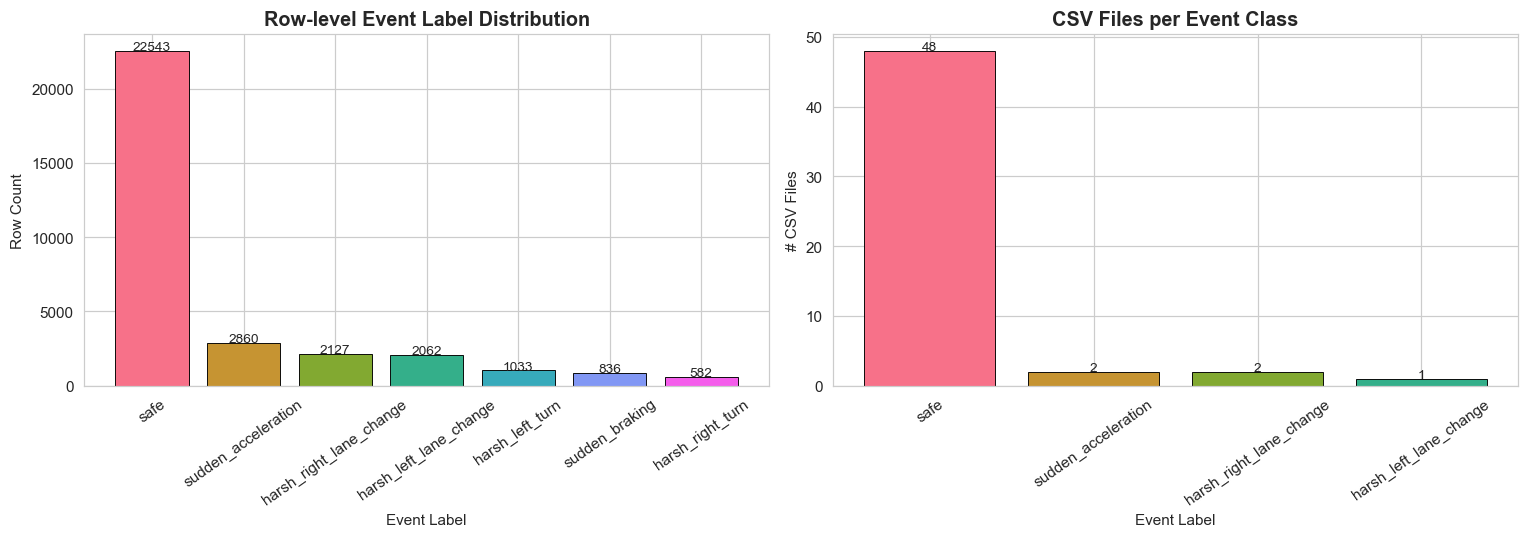

Class imbalance ratio (safe : rarest class): 38.7


In [4]:
# ── Cell 5: Exploratory Data Analysis ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Row-level distribution
label_counts = raw_df["event_label"].value_counts()
colors = sns.color_palette("husl", len(label_counts))
axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor="black", linewidth=0.6)
axes[0].set_title("Row-level Event Label Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Event Label")
axes[0].set_ylabel("Row Count")
axes[0].tick_params(axis="x", rotation=35)
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontsize=9)

# Per-file recording count
file_event = (
    raw_df.groupby("source_file")["event_label"]
    .apply(lambda s: s.value_counts().idxmax())
    .reset_index()
    .rename(columns={"event_label": "dominant_label"})
)
file_label_counts = file_event["dominant_label"].value_counts()
axes[1].bar(file_label_counts.index, file_label_counts.values, color=colors[:len(file_label_counts)], edgecolor="black", linewidth=0.6)
axes[1].set_title("CSV Files per Event Class", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Event Label")
axes[1].set_ylabel("# CSV Files")
axes[1].tick_params(axis="x", rotation=35)
for i, v in enumerate(file_label_counts.values):
    axes[1].text(i, v + 0.1, str(v), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "label_distribution.png", bbox_inches="tight")
plt.show()
print("Class imbalance ratio (safe : rarest class):",
      round(label_counts["safe"] / label_counts.min(), 1))

In [5]:
# ── Cell 6: Enhanced Window Feature Extraction (25+ stats per channel) ────────

def extract_window_features(window_2d: np.ndarray, col_names: list) -> dict:
    """Extract 25+ statistical features per channel from a sliding window."""
    feats = {}

    for i, col in enumerate(col_names):
        x = window_2d[:, i].astype(np.float64)
        dx = np.diff(x)
        abs_x = np.abs(x)
        pos = x[x > 0]
        neg = x[x < 0]

        feats[f"{col}_mean"]         = np.mean(x)
        feats[f"{col}_std"]          = np.std(x)
        feats[f"{col}_min"]          = np.min(x)
        feats[f"{col}_max"]          = np.max(x)
        feats[f"{col}_range"]        = np.max(x) - np.min(x)
        feats[f"{col}_q25"]          = float(np.percentile(x, 25))
        feats[f"{col}_q75"]          = float(np.percentile(x, 75))
        feats[f"{col}_iqr"]          = float(np.percentile(x, 75) - np.percentile(x, 25))
        feats[f"{col}_rms"]          = float(np.sqrt(np.mean(x**2)))
        feats[f"{col}_energy"]       = float(np.sum(x**2))
        feats[f"{col}_abs_mean"]     = float(np.mean(abs_x))
        feats[f"{col}_abs_std"]      = float(np.std(abs_x))
        feats[f"{col}_abs_max"]      = float(np.max(abs_x))
        feats[f"{col}_skew"]         = float(skew(x)) if len(x) > 1 else 0.0
        feats[f"{col}_kurtosis"]     = float(kurtosis(x)) if len(x) > 1 else 0.0
        feats[f"{col}_delta"]        = float(x[-1] - x[0])
        feats[f"{col}_first"]        = float(x[0])
        feats[f"{col}_last"]         = float(x[-1])
        feats[f"{col}_pos_ratio"]    = float(np.count_nonzero(x > 0) / len(x))
        feats[f"{col}_neg_ratio"]    = float(np.count_nonzero(x < 0) / len(x))
        feats[f"{col}_pos_mean"]     = float(np.mean(pos)) if pos.size else 0.0
        feats[f"{col}_neg_mean"]     = float(np.mean(neg)) if neg.size else 0.0
        feats[f"{col}_diff_mean"]    = float(np.mean(dx))    if dx.size else 0.0
        feats[f"{col}_diff_std"]     = float(np.std(dx))     if dx.size else 0.0
        feats[f"{col}_diff_abs_max"] = float(np.max(np.abs(dx))) if dx.size else 0.0
        feats[f"{col}_diff_skew"]    = float(skew(dx))     if dx.size > 1 else 0.0
        feats[f"{col}_diff_kurt"]    = float(kurtosis(dx)) if dx.size > 1 else 0.0
        feats[f"{col}_zcr"] = float(np.count_nonzero(np.diff(np.sign(x))) / max(len(x)-1, 1))

    # ── Cross-sensor features ────────────────────────────────────────────────
    try:
        acc_x_idx  = col_names.index("acc_x")
        gyro_z_idx = col_names.index("gyro_z")
        acc_y_idx  = col_names.index("acc_y")
        acc_mag_idx = col_names.index("acc_mag") if "acc_mag" in col_names else None

        ax = window_2d[:, acc_x_idx]
        gz = window_2d[:, gyro_z_idx]
        ay = window_2d[:, acc_y_idx]

        corr_ax_gz = float(np.corrcoef(ax, gz)[0, 1]) if np.std(ax) > 0 and np.std(gz) > 0 else 0.0
        corr_ay_gz = float(np.corrcoef(ay, gz)[0, 1]) if np.std(ay) > 0 and np.std(gz) > 0 else 0.0
        feats["cross_corr_accx_gyroz"] = corr_ax_gz
        feats["cross_corr_accy_gyroz"] = corr_ay_gz

        peaks_ax, _ = find_peaks(np.abs(ax), height=np.mean(np.abs(ax)))
        peaks_gz, _ = find_peaks(np.abs(gz), height=np.mean(np.abs(gz)))
        feats["peak_count_accx"]  = float(len(peaks_ax))
        feats["peak_count_gyroz"] = float(len(peaks_gz))

        if acc_mag_idx is not None:
            am = window_2d[:, acc_mag_idx]
            feats["acc_mag_peak"] = float(np.max(am))
            feats["acc_mag_auc"]  = float(np.trapz(am))
    except Exception:
        pass

    return feats


def build_window_dataset(
    df: pd.DataFrame,
    feature_channels: list,
    window_size: int = 25,
    step_size: int = 5,
    min_event_ratio: float = 0.30,
):
    """Slide windows over each source file and compute features."""
    x_rows, y_rows, group_rows = [], [], []

    for file_name, g in df.groupby("source_file"):
        g = g.reset_index(drop=True)
        if len(g) < window_size:
            continue

        values = g[feature_channels].to_numpy(dtype=np.float32)
        labels = g["event_label"].to_numpy()

        for start in range(0, len(g) - window_size + 1, step_size):
            window_vals   = values[start : start + window_size]
            window_labels = labels[start : start + window_size]

            non_safe = window_labels[window_labels != "safe"]
            if len(non_safe) == 0 or (len(non_safe) / window_size) < min_event_ratio:
                target = "safe"
            else:
                target = Counter(non_safe).most_common(1)[0][0]

            feats = extract_window_features(window_vals, feature_channels)
            x_rows.append(feats)
            y_rows.append(target)
            group_rows.append(file_name)

    X = pd.DataFrame(x_rows).fillna(0.0)
    y = np.array(y_rows)
    groups = np.array(group_rows)
    return X, y, groups


print("Building windowed feature dataset...")
X_all, y_all, groups_all = build_window_dataset(
    clean_df,
    FEATURE_CHANNELS,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
    min_event_ratio=MIN_EVENT_RATIO,
)

print(f"\nFeature matrix shape : {X_all.shape}  ({X_all.shape[1]} features/window)")
print(f"Window count         : {len(y_all):,}")
print(f"\nWindow-level label distribution:")
print(pd.Series(y_all).value_counts())

Building windowed feature dataset...

Feature matrix shape : (6173, 510)  (510 features/window)
Window count         : 6,173

Window-level label distribution:
safe                       4148
sudden_acceleration         598
harsh_right_lane_change     458
harsh_left_lane_change      445
harsh_left_turn             217
sudden_braking              183
harsh_right_turn            124
Name: count, dtype: int64


In [6]:
# ── Cell 7: 3-Way Group Split (Train 70% / Val 15% / Test 15%) ────────────────
# Groups are source files → prevents same recording from leaking across splits.

ALL_LABELS = sorted(set(y_all))
NON_SAFE   = [l for l in ALL_LABELS if l != "safe"]
print(f"All labels: {ALL_LABELS}")

def find_best_split_seed(X, y, groups, test_size, seed_range=(SEED, SEED + 2000)):
    best_split, best_score = None, (-1, -1, -1)
    for s in range(*seed_range):
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=s)
        tr_idx, te_idx = next(gss.split(X, y, groups=groups))
        te_labels = set(y[te_idx])
        cov = sum(l in te_labels for l in NON_SAFE)
        score = (cov, len(te_labels), len(te_idx))
        if score > best_score:
            best_score = score
            best_split = (tr_idx, te_idx, s)
        if cov == len(NON_SAFE):
            break
    return best_split

# Step 1: Hold out test set (15%)
trainval_idx, test_idx, seed_test = find_best_split_seed(X_all, y_all, groups_all, test_size=0.15)
X_trainval, y_trainval, grp_trainval = X_all.iloc[trainval_idx], y_all[trainval_idx], groups_all[trainval_idx]
X_test,     y_test                   = X_all.iloc[test_idx],     y_all[test_idx]

# Step 2: Split trainval → train (82%) + val (18%)  →  gives ~70/15/15 overall
train_idx_local, val_idx_local, seed_val = find_best_split_seed(
    X_trainval, y_trainval, grp_trainval, test_size=0.18
)
X_train, y_train = X_trainval.iloc[train_idx_local], y_trainval[train_idx_local]
X_val,   y_val   = X_trainval.iloc[val_idx_local],   y_trainval[val_idx_local]

print(f"\nSplit sizes  — Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")
print(f"\nTrain label distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nVal label distribution:")
print(pd.Series(y_val).value_counts())
print(f"\nTest label distribution:")
print(pd.Series(y_test).value_counts())

# Encode labels
le = LabelEncoder()
le.fit(ALL_LABELS)
y_train_enc = le.transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

print(f"\nEncoded classes: {list(zip(le.classes_, le.transform(le.classes_)))}")

All labels: ['harsh_left_lane_change', 'harsh_left_turn', 'harsh_right_lane_change', 'harsh_right_turn', 'safe', 'sudden_acceleration', 'sudden_braking']

Split sizes  — Train: 4,226  Val: 989  Test: 958

Train label distribution:
safe                       2905
sudden_acceleration         496
harsh_right_lane_change     269
harsh_left_lane_change      204
sudden_braking              149
harsh_left_turn             138
harsh_right_turn             65
Name: count, dtype: int64

Val label distribution:
safe                       628
harsh_left_lane_change     123
harsh_right_lane_change     96
sudden_acceleration         46
harsh_left_turn             46
harsh_right_turn            30
sudden_braking              20
Name: count, dtype: int64

Test label distribution:
safe                       615
harsh_left_lane_change     118
harsh_right_lane_change     93
sudden_acceleration         56
harsh_left_turn             33
harsh_right_turn            29
sudden_braking              14
Name: co

In [7]:
# ── Cell 8: SMOTE Oversampling on Training Split ──────────────────────────────
# Applied ONLY to the training data — val/test remain untouched.

print("Before SMOTE:")
print(pd.Series(y_train_enc).value_counts().rename(index=dict(enumerate(le.classes_))))

smote = SMOTE(
    random_state=SEED,
    k_neighbors=min(5, pd.Series(y_train_enc).value_counts().min() - 1),
)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train_enc)

print("\nAfter SMOTE:")
print(pd.Series(y_train_res).value_counts().rename(index=dict(enumerate(le.classes_))))
print(f"\nTraining samples: {len(X_train):,} → {len(X_train_res):,} after SMOTE")

Before SMOTE:
safe                       2905
sudden_acceleration         496
harsh_right_lane_change     269
harsh_left_lane_change      204
sudden_braking              149
harsh_left_turn             138
harsh_right_turn             65
Name: count, dtype: int64

After SMOTE:
safe                       2905
sudden_acceleration        2905
sudden_braking             2905
harsh_left_lane_change     2905
harsh_left_turn            2905
harsh_right_lane_change    2905
harsh_right_turn           2905
Name: count, dtype: int64

Training samples: 4,226 → 20,335 after SMOTE


In [8]:
# ── Cell 9: Baseline XGBoost ──────────────────────────────────────────────────

baseline_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(le.classes_),
    tree_method="hist",
    eval_metric="mlogloss",
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)

baseline_model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_val, y_val_enc)],
    verbose=False,
)

y_val_pred_base = baseline_model.predict(X_val)
macro_f1_base   = f1_score(y_val_enc, y_val_pred_base, average="macro", zero_division=0)
print(f"Baseline macro-F1 on val: {macro_f1_base:.4f}")
print(classification_report(
    y_val_enc, y_val_pred_base,
    target_names=list(le.classes_),
    digits=4, zero_division=0
))

Baseline macro-F1 on val: 0.3330
                         precision    recall  f1-score   support

 harsh_left_lane_change     0.4045    0.2927    0.3396       123
        harsh_left_turn     0.0789    0.0652    0.0714        46
harsh_right_lane_change     0.4375    0.4375    0.4375        96
       harsh_right_turn     0.0588    0.0333    0.0426        30
                   safe     0.8259    0.8838    0.8538       628
    sudden_acceleration     0.2740    0.4348    0.3361        46
         sudden_braking     0.7500    0.1500    0.2500        20

               accuracy                         0.6673       989
              macro avg     0.4042    0.3282    0.3330       989
           weighted avg     0.6506    0.6673    0.6522       989



  0%|          | 0/30 [00:00<?, ?it/s]


Completed 13 trials (budget: 30 trials / 600s)
Best macro-F1 (val) : 0.3516
Best params          : {'n_estimators': 350, 'max_depth': 3, 'learning_rate': 0.10105986956106063, 'subsample': 0.6118811941888151, 'colsample_bytree': 0.624085083650476, 'min_child_weight': 18, 'gamma': 1.5408963486810046, 'reg_alpha': 3.5698500206593926, 'reg_lambda': 3.1721514393228305}


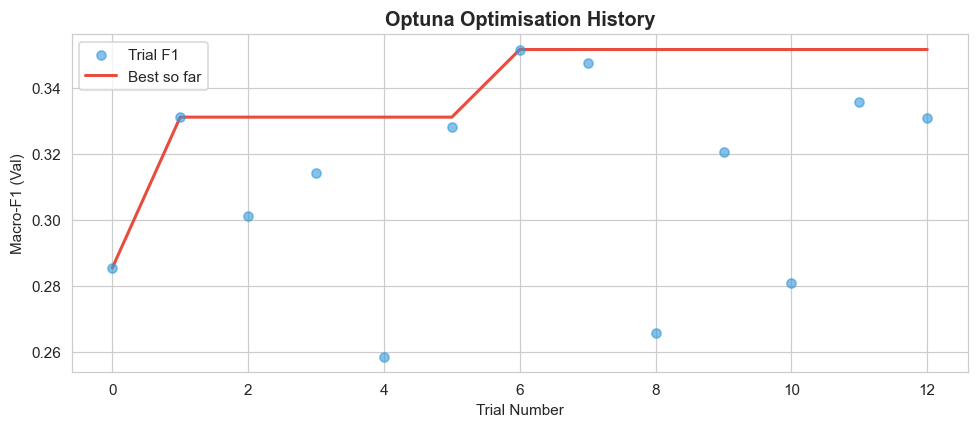

In [9]:
# ── Cell 10: Optuna Hyperparameter Search ─────────────────────────────────────
# Searches 9 XGBoost hyperparameters, maximising macro-F1 on validation set.
#
# ⚡ Speed optimisations vs original:
#   • n_estimators capped at 500 (was 1000) — ~2x faster per trial
#   • early_stopping_rounds=10 inside each trial — kills bad configs early
#   • timeout=600 on study.optimize() — hard 10-min wall-clock budget
#   • n_jobs=1 in XGBoost — avoids thread-pool conflicts with Optuna
#   • Optuna visualization uses pure matplotlib (no extra dependency needed)

N_TRIALS        = 30   # number of Optuna trials (reduce to 15 if still slow)
TIMEOUT_SECONDS = 600  # hard stop after 10 minutes regardless of trials left

def objective(trial: optuna.Trial) -> float:
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 500, step=50),
        "max_depth":        trial.suggest_int("max_depth", 3, 9),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "gamma":            trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1.0, 10.0),
    }

    clf = xgb.XGBClassifier(
        **params,
        objective="multi:softprob",
        num_class=len(le.classes_),
        tree_method="hist",
        eval_metric="mlogloss",
        early_stopping_rounds=10,   # stop trial early if val doesn't improve
        random_state=SEED,
        n_jobs=1,                   # 1 thread per trial; avoids conflicts
        verbosity=0,
    )
    clf.fit(
        X_train_res, y_train_res,
        eval_set=[(X_val, y_val_enc)],
        verbose=False,
    )
    preds = clf.predict(X_val)
    return f1_score(y_val_enc, preds, average="macro", zero_division=0)


study = optuna.create_study(direction="maximize", study_name="xgb_harsh_driving_v2")
study.optimize(
    objective,
    n_trials=N_TRIALS,
    timeout=TIMEOUT_SECONDS,  # hard stop after 10 minutes
    n_jobs=1,
    show_progress_bar=True,
)

best_params = study.best_params
print(f"\nCompleted {len(study.trials)} trials (budget: {N_TRIALS} trials / {TIMEOUT_SECONDS}s)")
print(f"Best macro-F1 (val) : {study.best_value:.4f}")
print(f"Best params          : {best_params}")

# ── Optimisation history (pure matplotlib — no optuna[visualization] needed) ──
trial_numbers = [t.number for t in study.trials if t.value is not None]
trial_values  = [t.value  for t in study.trials if t.value is not None]
best_so_far   = [max(trial_values[:i+1]) for i in range(len(trial_values))]

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(trial_numbers, trial_values, alpha=0.6, color="#3498db", label="Trial F1", zorder=3)
ax.plot(trial_numbers, best_so_far, color="#e74c3c", linewidth=2, label="Best so far")
ax.set_xlabel("Trial Number")
ax.set_ylabel("Macro-F1 (Val)")
ax.set_title("Optuna Optimisation History", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "optuna_history.png", bbox_inches="tight")
plt.show()

Best iteration (early stopping): 120


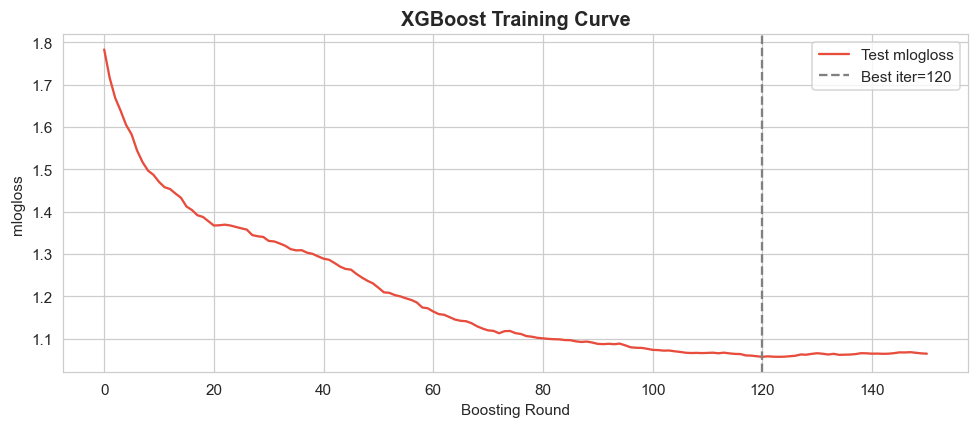

In [10]:
# ── Cell 11: Final Model Training ────────────────────────────────────────────
# Combine train + val for final training, test set for early-stopping signal.

# Merge train (post-SMOTE) and val
X_trainval_res = pd.concat([X_train_res, X_val], ignore_index=True)
y_trainval_res = np.concatenate([y_train_res, y_val_enc])

final_model = xgb.XGBClassifier(
    **best_params,
    objective="multi:softprob",
    num_class=len(le.classes_),
    tree_method="hist",
    eval_metric="mlogloss",
    early_stopping_rounds=30,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)

final_model.fit(
    X_trainval_res, y_trainval_res,
    eval_set=[(X_test, y_test_enc)],
    verbose=False,
)

print(f"Best iteration (early stopping): {final_model.best_iteration}")

# Training curve
evals_result = final_model.evals_result()
plt.figure(figsize=(9, 4))
plt.plot(evals_result["validation_0"]["mlogloss"], label="Test mlogloss", color="#e74c3c")
plt.axvline(x=final_model.best_iteration, linestyle="--", color="gray", label=f"Best iter={final_model.best_iteration}")
plt.xlabel("Boosting Round")
plt.ylabel("mlogloss")
plt.title("XGBoost Training Curve", fontsize=13, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "training_curve.png", bbox_inches="tight")
plt.show()

In [11]:
# ── Cell 12: Full Evaluation on Test Set ──────────────────────────────────────

y_test_pred  = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)

CLASS_NAMES = list(le.classes_)
N_CLASSES   = len(CLASS_NAMES)

# ── Classification Report ─────────────────────────────────────────────────────
report = classification_report(
    y_test_enc, y_test_pred,
    labels=np.arange(N_CLASSES),
    target_names=CLASS_NAMES,
    digits=4, zero_division=0
)
print("Test Set Classification Report:")
print(report)

macro_f1_final = f1_score(y_test_enc, y_test_pred, average="macro", zero_division=0)
print(f"▶  Macro-F1  (test) : {macro_f1_final:.4f}")
print(f"▶  Baseline macro-F1: {macro_f1_base:.4f}")
print(f"▶  Improvement      : +{macro_f1_final - macro_f1_base:+.4f}")

Test Set Classification Report:
                         precision    recall  f1-score   support

 harsh_left_lane_change     0.3689    0.3220    0.3439       118
        harsh_left_turn     0.0500    0.0606    0.0548        33
harsh_right_lane_change     0.6000    0.0968    0.1667        93
       harsh_right_turn     0.3818    0.7241    0.5000        29
                   safe     0.7815    0.8374    0.8085       615
    sudden_acceleration     0.0000    0.0000    0.0000        56
         sudden_braking     0.3684    0.5000    0.4242        14

               accuracy                         0.6180       958
              macro avg     0.3644    0.3630    0.3283       958
           weighted avg     0.6240    0.6180    0.6008       958

▶  Macro-F1  (test) : 0.3283
▶  Baseline macro-F1: 0.3330
▶  Improvement      : +-0.0047


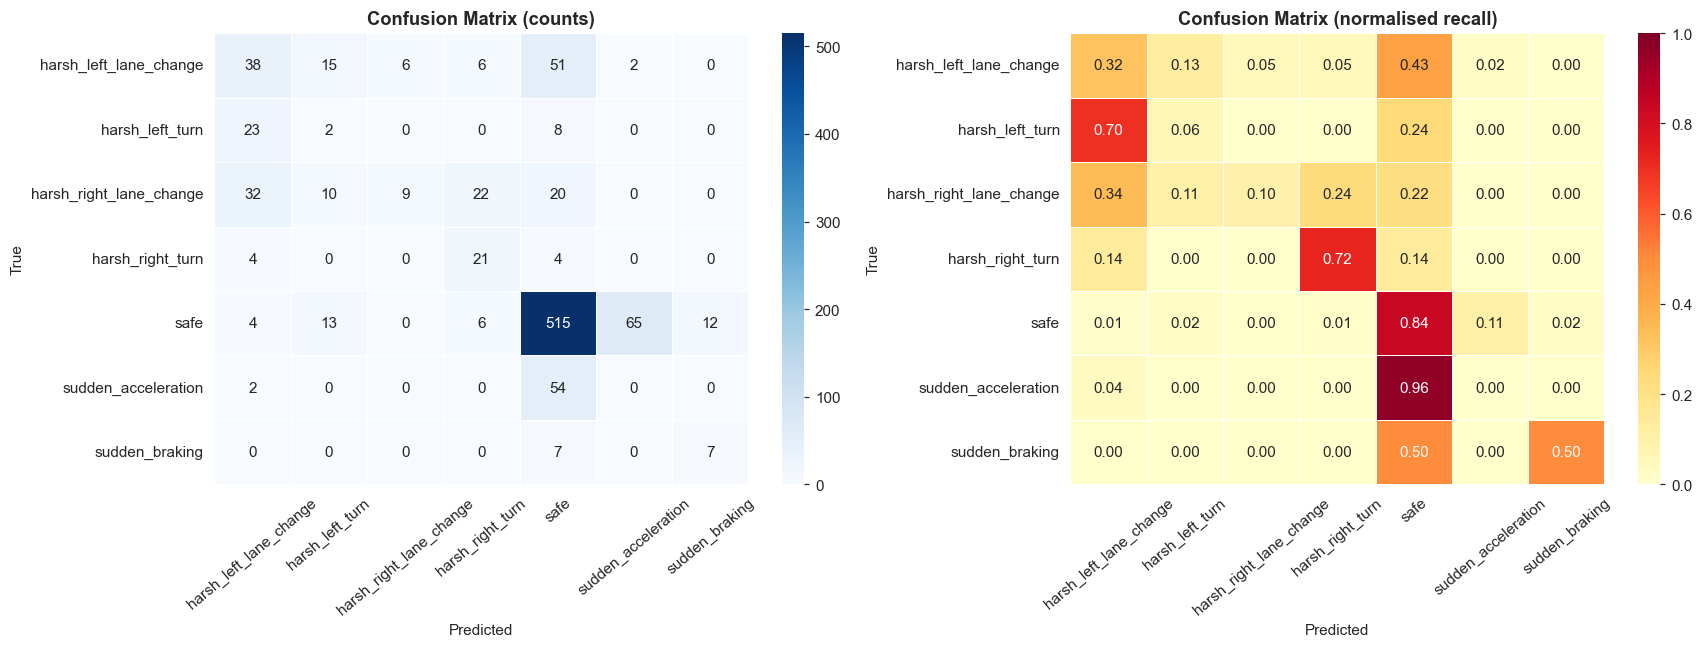

In [12]:
# ── Cell 12b: Confusion Matrix ───────────────────────────────────────────────

cm = confusion_matrix(y_test_enc, y_test_pred, labels=np.arange(N_CLASSES))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, ax=axes[0]
)
axes[0].set_title("Confusion Matrix (counts)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].tick_params(axis="x", rotation=40)
axes[0].tick_params(axis="y", rotation=0)

# Normalised
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="YlOrRd",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, vmin=0, vmax=1, ax=axes[1]
)
axes[1].set_title("Confusion Matrix (normalised recall)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].tick_params(axis="x", rotation=40)
axes[1].tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "confusion_matrix.png", bbox_inches="tight")
plt.show()

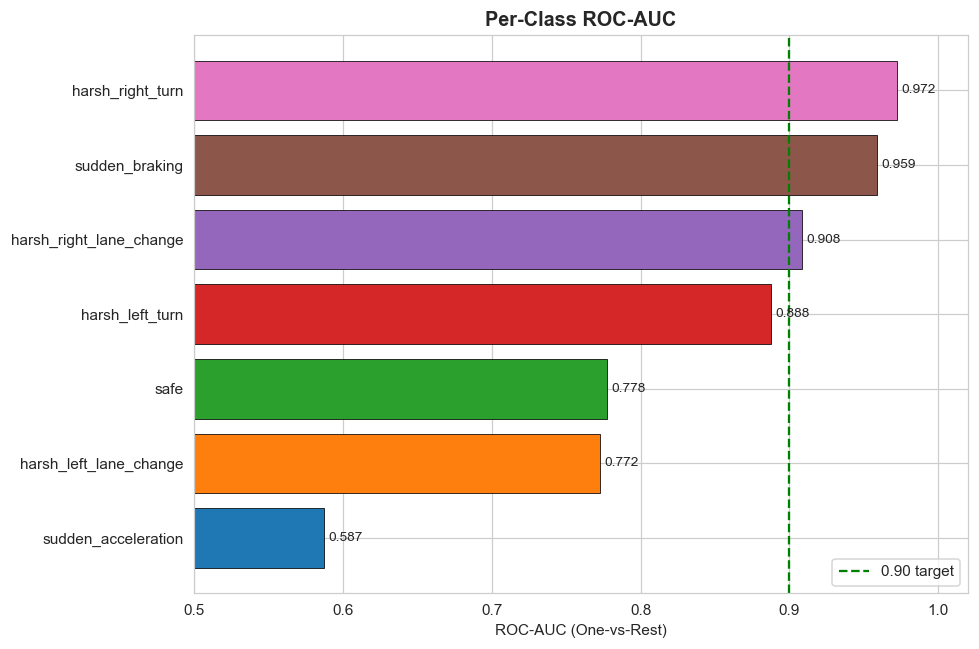

Macro ROC-AUC: 0.8378


In [13]:
# ── Cell 12c: Per-Class ROC-AUC ───────────────────────────────────────────────

y_test_bin = label_binarize(y_test_enc, classes=np.arange(N_CLASSES))

fig, ax = plt.subplots(figsize=(9, 6))
palette  = sns.color_palette("tab10", N_CLASSES)
auc_scores = []

for i, cls in enumerate(CLASS_NAMES):
    try:
        auc = roc_auc_score(y_test_bin[:, i], y_test_proba[:, i])
    except Exception:
        auc = float("nan")
    auc_scores.append(auc)

auc_df = pd.DataFrame({"class": CLASS_NAMES, "ROC-AUC": auc_scores}).sort_values("ROC-AUC")
bars = ax.barh(auc_df["class"], auc_df["ROC-AUC"], color=palette, edgecolor="black", linewidth=0.5)
ax.axvline(x=0.9, linestyle="--", color="green", label="0.90 target")
ax.set_xlim(0.5, 1.02)
ax.set_xlabel("ROC-AUC (One-vs-Rest)")
ax.set_title("Per-Class ROC-AUC", fontsize=13, fontweight="bold")
for bar, v in zip(bars, auc_df["ROC-AUC"]):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f"{v:.3f}", va="center", fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "roc_auc.png", bbox_inches="tight")
plt.show()

print("Macro ROC-AUC:", round(np.nanmean(auc_scores), 4))

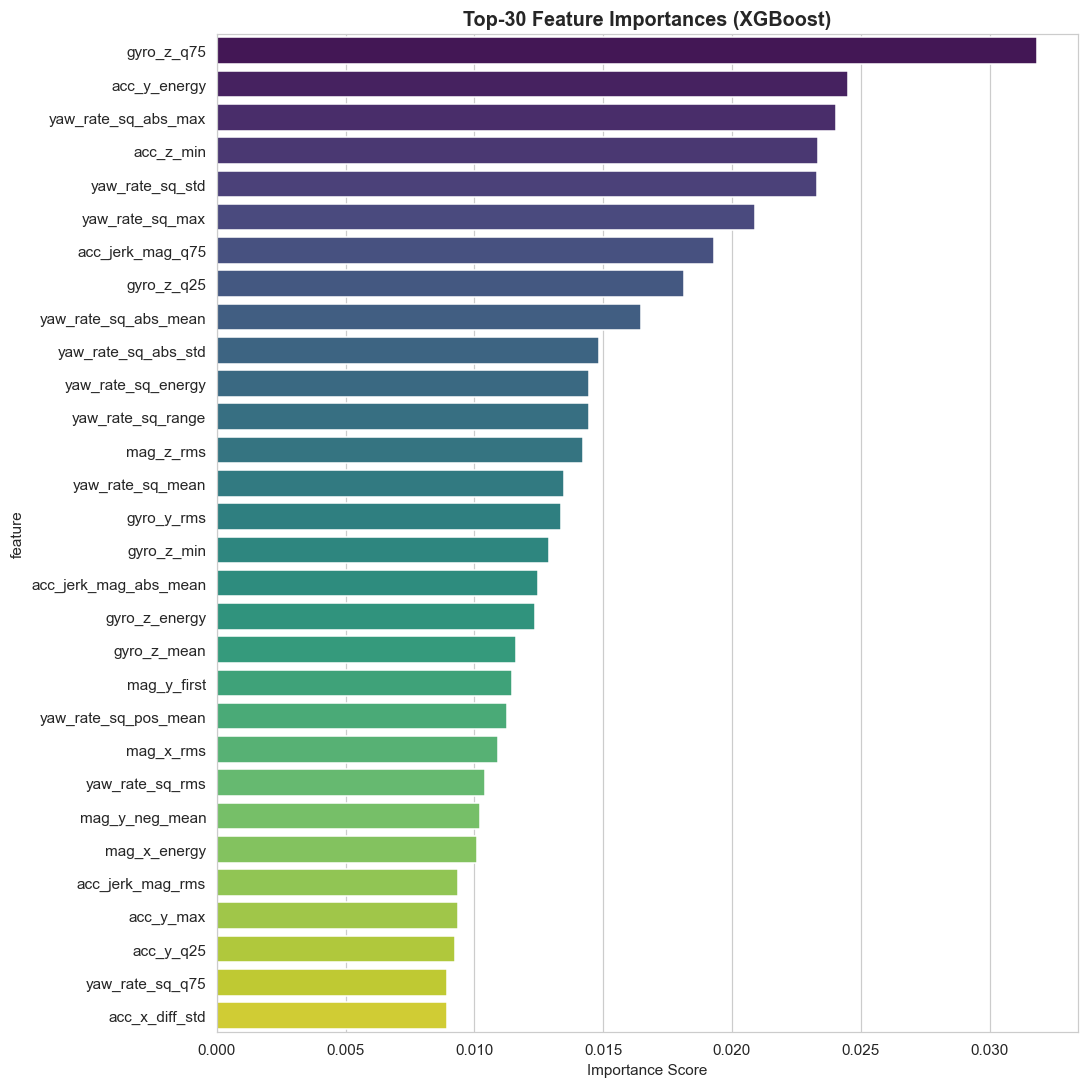


Top-10 features:
             feature  importance
          gyro_z_q75    0.031843
        acc_y_energy    0.024489
 yaw_rate_sq_abs_max    0.024052
           acc_z_min    0.023337
     yaw_rate_sq_std    0.023310
     yaw_rate_sq_max    0.020875
    acc_jerk_mag_q75    0.019282
          gyro_z_q25    0.018125
yaw_rate_sq_abs_mean    0.016475
 yaw_rate_sq_abs_std    0.014836


In [14]:
# ── Cell 12d: Feature Importance (Top-30) ────────────────────────────────────

importances = final_model.feature_importances_
feat_df = pd.DataFrame({
    "feature":    X_all.columns,
    "importance": importances
}).sort_values("importance", ascending=False).head(30)

fig, ax = plt.subplots(figsize=(10, 10))
sns.barplot(
    data=feat_df, y="feature", x="importance",
    palette="viridis", ax=ax, orient="h"
)
ax.set_title("Top-30 Feature Importances (XGBoost)", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "feature_importance.png", bbox_inches="tight")
plt.show()

print("\nTop-10 features:")
print(feat_df[["feature", "importance"]].head(10).to_string(index=False))

Top-10 most confused class pairs (True → Predicted):
safe → sudden_acceleration                          65
sudden_acceleration → safe                          54
harsh_left_lane_change → safe                       51
harsh_right_lane_change → harsh_left_lane_change    32
harsh_left_turn → harsh_left_lane_change            23
harsh_right_lane_change → harsh_right_turn          22
harsh_right_lane_change → safe                      20
harsh_left_lane_change → harsh_left_turn            15
safe → harsh_left_turn                              13
safe → sudden_braking                               12


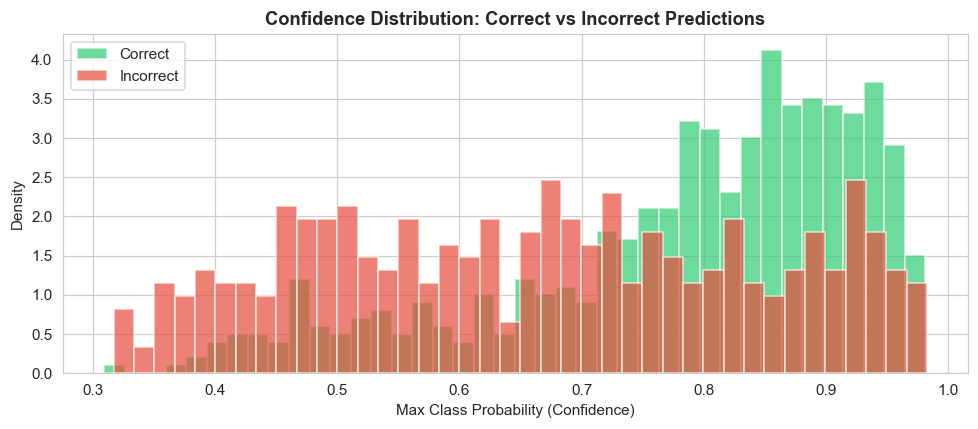


Median confidence — Correct: 0.825  |  Incorrect: 0.668


In [15]:
# ── Cell 13: Error Analysis ───────────────────────────────────────────────────

# Identify most-confused class pairs
errors_mask = y_test_pred != y_test_enc
error_true  = le.inverse_transform(y_test_enc[errors_mask])
error_pred  = le.inverse_transform(y_test_pred[errors_mask])

confusion_pairs = pd.Series(
    [f"{t} → {p}" for t, p in zip(error_true, error_pred)]
).value_counts().head(10)

print("Top-10 most confused class pairs (True → Predicted):")
print(confusion_pairs.to_string())

# ── Confidence distribution of errors vs correct ──────────────────────────────
max_proba = y_test_proba.max(axis=1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(max_proba[~errors_mask], bins=40, alpha=0.7, label="Correct",  color="#2ecc71", density=True)
ax.hist(max_proba[errors_mask],  bins=40, alpha=0.7, label="Incorrect", color="#e74c3c", density=True)
ax.set_xlabel("Max Class Probability (Confidence)")
ax.set_ylabel("Density")
ax.set_title("Confidence Distribution: Correct vs Incorrect Predictions", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "error_confidence.png", bbox_inches="tight")
plt.show()

print(f"\nMedian confidence — Correct: {np.median(max_proba[~errors_mask]):.3f}  |  Incorrect: {np.median(max_proba[errors_mask]):.3f}")

In [16]:
# ── Cell 14: Export CARLA-Compatible Model Bundle ─────────────────────────────
# The bundle format matches exactly what RealtimeHarshEventDetector expects.

# Wrap in a sklearn Pipeline (scaler + xgb) so .predict_proba works identically
scaler = StandardScaler()
scaler.fit(X_trainval_res)  # fit on train+val (post-SMOTE)

xgb_pipeline = Pipeline(steps=[
    ("scaler", scaler),
    ("xgb",    final_model),
])

# Verify pipeline predict_proba works
test_proba_pipeline = xgb_pipeline.predict_proba(X_test)
assert test_proba_pipeline.shape == (len(X_test), len(le.classes_)), "Shape mismatch!"

bundle = {
    "model":           xgb_pipeline,
    "label_encoder":   le,
    "feature_columns": list(X_all.columns),
    "window_size":     WINDOW_SIZE,
    "step_size":       STEP_SIZE,
    "min_event_ratio": MIN_EVENT_RATIO,
    "imu_columns":     IMU_COLUMNS,
    # Metadata
    "model_type":      "xgboost_v2",
    "feature_channels": FEATURE_CHANNELS,
    "n_classes":       len(le.classes_),
    "class_names":     CLASS_NAMES,
    "macro_f1_test":   round(macro_f1_final, 4),
    "best_xgb_params": best_params,
}

BUNDLE_PATH = ARTIFACTS_DIR / "harsh_event_xgb_v2.joblib"
joblib.dump(bundle, BUNDLE_PATH, protocol=4)

print(f"Model bundle saved to: {BUNDLE_PATH}")
print(f"   Bundle keys: {list(bundle.keys())}")
print(f"   Macro-F1 (test): {macro_f1_final:.4f}")

Model bundle saved to: C:\Users\vigne\OneDrive\Desktop\Capstone\carla-project\notebooks\artifacts\harsh_event_xgb_v2.joblib
   Bundle keys: ['model', 'label_encoder', 'feature_columns', 'window_size', 'step_size', 'min_event_ratio', 'imu_columns', 'model_type', 'feature_channels', 'n_classes', 'class_names', 'macro_f1_test', 'best_xgb_params']
   Macro-F1 (test): 0.3283


In [17]:
# ── Cell 14b: Smoke-Test — Simulate RealtimeHarshEventDetector ───────────────
# Verifies the saved bundle works end-to-end with the realtime detector.

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from harsh_event_model import RealtimeHarshEventDetector

detector = RealtimeHarshEventDetector(
    model_bundle_path=BUNDLE_PATH,
    min_confidence=0.40,
    consecutive_hits=1,
    heuristic_enabled=True,
)

# Feed 30 IMU samples from first rows of clean_df
sample_df = clean_df[IMU_COLUMNS].head(30)
last_result = None
for _, row in sample_df.iterrows():
    result = detector.update(row.to_dict())
    if result is not None and result.get("ready"):
        last_result = result

print("Smoke-test passed!")
print(f"Last detector output: {last_result}")

C:\Users\vigne\OneDrive\Desktop\Capstone\carla-project\src\harsh_event_model.py:392: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  row[feature_name] = 0.0
C:\Users\vigne\OneDrive\Desktop\Capstone\carla-project\src\harsh_event_model.py:392: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  row[feature_name] = 0.0
C:\Users\vigne\OneDrive\Desktop\Capstone\carla-project\src\harsh_event_model.py:392: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfor

Smoke-test passed!
Last detector output: {'ready': True, 'raw_prediction': 'safe', 'prediction': 'safe', 'confidence': 0.9737837910652161, 'probabilities': {'harsh_left_lane_change': 0.008287066593766212, 'harsh_left_turn': 0.0019582146778702736, 'harsh_right_lane_change': 0.011977669782936573, 'harsh_right_turn': 0.0017991212662309408, 'safe': 0.9737837910652161, 'sudden_acceleration': 0.0013464994262903929, 'sudden_braking': 0.0008475970244035125}}


C:\Users\vigne\OneDrive\Desktop\Capstone\carla-project\src\harsh_event_model.py:392: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  row[feature_name] = 0.0
C:\Users\vigne\OneDrive\Desktop\Capstone\carla-project\src\harsh_event_model.py:392: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  row[feature_name] = 0.0
C:\Users\vigne\OneDrive\Desktop\Capstone\carla-project\src\harsh_event_model.py:392: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfor

# Cell 15 — CARLA Real-Time Usage Guide

## Quick Start

After this notebook completes, the model bundle is saved at:
```
notebooks/artifacts/harsh_event_xgb_v2.joblib
```

Run in your CARLA environment:

```bash
cd src/
python run_carla_realtime.py \
    --model-path ../notebooks/artifacts/harsh_event_xgb_v2.joblib \
    --min-confidence 0.45 \
    --consecutive-hits 2 \
    --sensor-tick 0.05 \
    --heuristic
```

## Key Parameters to Tune

| Flag | Default | Tip |
|---|---|---|
| `--min-confidence` | `0.45` | Lower (0.35) = more detections, more false positives |
| `--consecutive-hits` | `2` | Higher = smoother, more latency |
| `--sensor-tick` | `0.05` | Matches 20 Hz IMU; don't change |
| `--invert-gyro-z` | off | Enable if left/right turns are swapped |
| `--invert-acc-y` | off | Enable if left/right lane changes are swapped |
| `--heuristic` | off | Enable as fallback when ML confidence is low |

## Timing

- **Warm-up**: `window_size=25 × sensor_tick=0.05s = 1.25 s` before first prediction
- **Prediction cadence**: Every `step_size=5` ticks = every **0.25 s** (4 Hz)
- **Inference latency**: <5 ms on CPU (XGBoost is fast)

## Recommended CARLA Test Scenario

1. Spawn ego vehicle in CARLA Town04 (highway) or Town03 (urban)
2. Enable manual control: `python manual_control.py --rolename hero`
3. In a separate terminal run `run_carla_realtime.py` with the XGBv2 bundle
4. Perform: hard brake, sharp U-turn, aggressive lane change
5. Observe `>>> HARSH EVENT: ...` outputs in the terminal